# <center> Logistic Regression on simulated data
    
Authors: Rémi LELUC, François PORTIER

### Import Libraries

In [16]:
import numpy as np
import matplotlib.pyplot as plt

### Tool function to load the results

In [17]:
def load(method='ridge',d=20):
    ''' Load the results of 'ridge' or 'logistic' regression
    in dimension d=20 or d=100
    '''
    loss_sgd = np.load('results/'+method+'_sgd_n5000_d{}.npy'.format(d))
    loss_sgd_avg = np.load('results/'+method+'_sgd_avg_n5000_d{}.npy'.format(d))
    loss_equal = np.load('results/'+method+'_equal_n5000_d{}.npy'.format(d))
    loss_weighted = np.load('results/'+method+'_weighted_n5000_d{}.npy'.format(d))
    return loss_sgd,loss_sgd_avg,loss_equal,loss_weighted

### Load results

In [24]:
loss_sgd,loss_sgd_avg,loss_equal,loss_weighted = load(method='ridge',d=20)
# loss_sgd,loss_sgd_avg,loss_equal,loss_weighted = load(method='ridge',d=100)
#loss_sgd,loss_sgd_avg,loss_equal,loss_weighted = load(method='logistic',d=20)
#loss_sgd,loss_sgd_avg,loss_equal,loss_weighted = load(method='logistic',d=100)

### Compute means and standard deviations

In [25]:
mean_sgd = np.mean(loss_sgd,axis=0)
mean_sgd_avg = np.mean(loss_sgd_avg,axis=0)
mean_equal = np.mean(loss_equal,axis=0)
mean_weighted = np.mean(loss_weighted,axis=0)

std_sgd = np.std(loss_sgd,axis=0)/2
std_sgd_avg = np.std(loss_sgd_avg,axis=0)/2
std_equal = np.std(loss_equal,axis=0)/2
std_weighted = np.std(loss_weighted,axis=0)/2

### Plot Figures

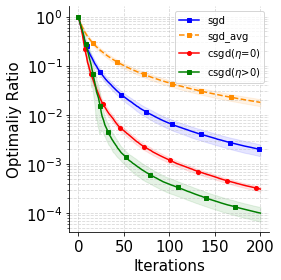

In [26]:
N=200
tab = np.arange(N+1)
fig,ax = plt.subplots(figsize=(4,4))
# SGD curves
plt.plot(mean_sgd/mean_sgd[0],
         color='b',label='sgd',
         linestyle='-',marker='s',markevery=0.1,ms=4)
plt.fill_between(tab,
                 (mean_sgd-std_sgd)/mean_sgd[0],
                 (mean_sgd+std_sgd)/mean_sgd[0],
                  color='b',alpha=0.1)
# Polyak-averaging curves
plt.plot(mean_sgd_avg/mean_sgd_avg[0],
         color='darkorange',label='sgd_avg',
         linestyle='--',marker='s',markevery=0.1,ms=4)
plt.fill_between(tab,
                 (mean_sgd_avg-std_sgd_avg)/mean_sgd_avg[0],
                 (mean_sgd_avg+std_sgd_avg)/mean_sgd_avg[0],
                  color='darkorange',alpha=0.1)
# C-SGD equal curves
plt.plot(mean_equal/mean_equal[0],
         color='red',label=r'csgd($\eta$=0)',
         linestyle='-',marker='o',markevery=0.1,ms=4)
plt.fill_between(tab,
                 (mean_equal-std_equal)/mean_equal[0],
                 (mean_equal+std_equal)/mean_equal[0],
                  color='red',alpha=0.1)
# C-SGD weighted curves
plt.plot(mean_weighted/mean_weighted[0],
         color='green',label=r'csgd($\eta$>0)',
         linestyle='-',marker='s',markevery=0.1,ms=4)
plt.fill_between(tab,
                 (mean_weighted-std_weighted)/mean_weighted[0],
                 (mean_weighted+std_weighted)/mean_weighted[0],
                  color='green',alpha=0.1)
# Graphics and Layout
plt.yscale('log')
plt.ylabel(r'Optimaliy Ratio',fontsize=15)
plt.xlabel('Iterations',fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=15)
plt.legend(loc='upper right',fontsize=10)
plt.grid(linestyle='--',which='both',alpha=0.5)
plt.tight_layout()
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# Uncomment to save figure
#plt.savefig('ridge_n5000_d20.pdf',bbox_inches='tight',transparent=True,pad_inches=0)
#plt.savefig('ridge_n5000_d100.pdf',bbox_inches='tight',transparent=True,pad_inches=0)
#plt.savefig('logistic_n5000_d20.pdf',bbox_inches='tight',transparent=True,pad_inches=0)
#plt.savefig('logistic_n5000_d100.pdf',bbox_inches='tight',transparent=True,pad_inches=0)
plt.show()